# 常见网络类型
想象一下，我们正在教一个孩子识别猫和狗。

最初，我们会给他看很多猫和狗的图片，并告诉他这是猫、这是狗，慢慢地，孩子的大脑会从这些图片中总结出规律：猫的耳朵通常是尖的，脸比较圆；狗的耳朵可能下垂，脸型更长，这个过程，本质上就是学习特征和建立模式.

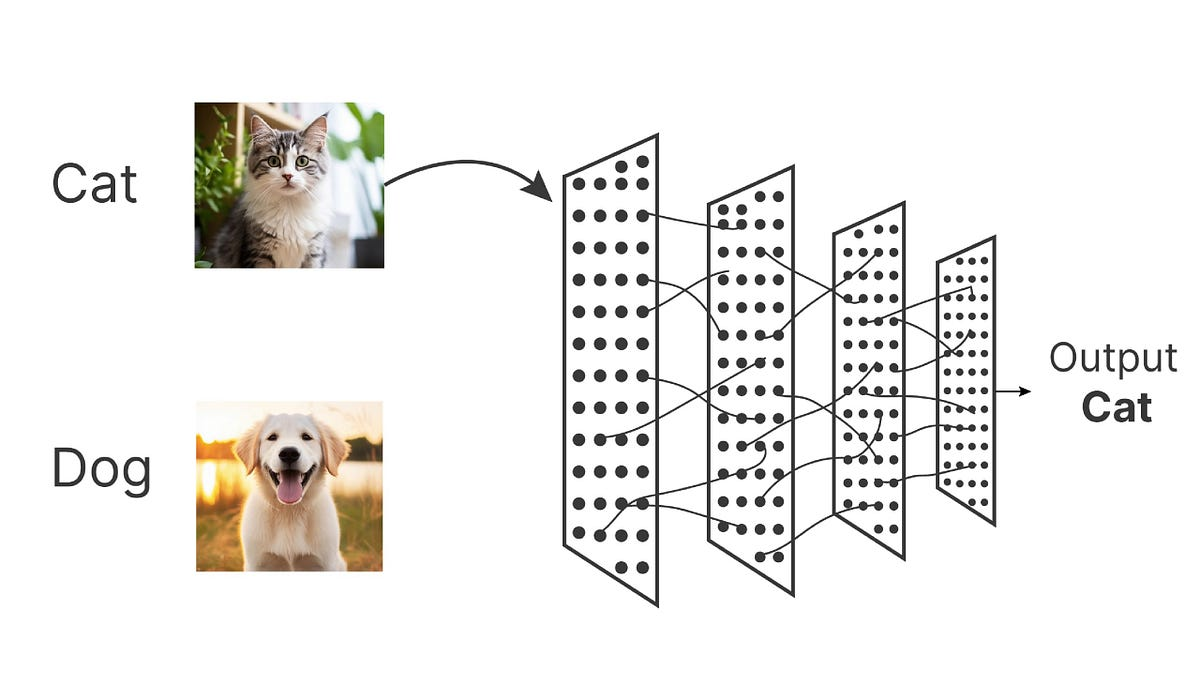

深度学习，作为机器学习的一个强大分支，其核心就是让计算机模拟这个过程，它通过构建多层的神经网络，让机器能够自动从海量数据中学习并提取复杂的特征，最终完成识别图像、理解语言、预测趋势等高级任务。而不同的任务，需要不同结构的网络来处理。本文将带你了解几种最核心、最常见的深度学习网络类型，理解它们的设计思想与典型应用。

----

## 深度学习网络类型
|中文全称|英文全称|简写|
|---|---|---|
|卷积神经网络|Convolutional Neural Network|CNN|
|循环神经网络|Recurrent Neural Network|RNN|
|生成对抗网络|Generative Adversarial Network|GAN|
|变分自编码器|Variational Autoencoder|VAE|
|图神经网络|Graph Neural Network|GNN|
|Transformer网络|Transformer Network|Transformer|
|注意力机制网络|Attention Mechanism Network|Attention|
|残差网络|Residual Network|ResNet|
|全连接神经网络|Fully Connected Neural Network|FCN|
|自编码器|Autoencoder|AE|
|长短期记忆网络|Long Short-Term Memory Network|LSTM|
|门控循环单元网络|Gated Recurrent Unit Network|GRU|
|深度信念网络|Deep Belief Network|DBN|

----

## 神经网络基础与全连接网络

在深入各类网络之前，我们需要理解最基础的模型——全连接网络，也称为多层感知机

### 核心思想 : 万物皆可连接
全连接网络的核心思想是：每一层的每一个神经元都与下一层的每一个神经元相连接。这种结构使得网络能够捕捉输入数据中的复杂关系和模式。全连接网络的每一层都可以看作是一个函数，它将输入数据映射到输出空间，通过学习权重和偏置，网络能够拟合各种复杂的函数关系。

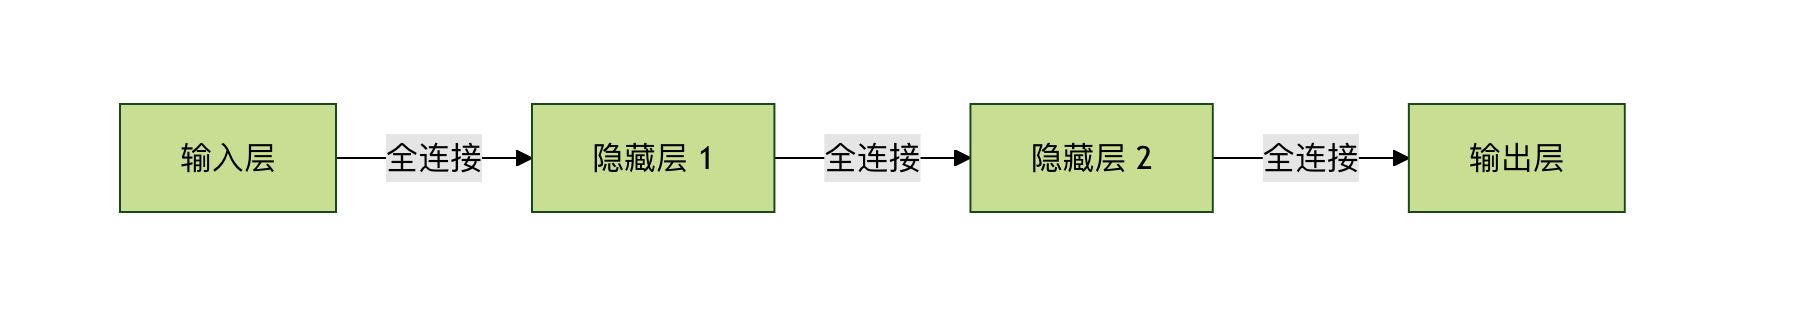

我们可以把他想象成一个极其密集的信息处理网络 , 数据从输入层进入，经过多个隐藏层的处理，最终在输出层得到结果。每一层的神经元都在学习如何从输入数据中提取有用的特征，并将这些特征传递给下一层进行更高层次的抽象。

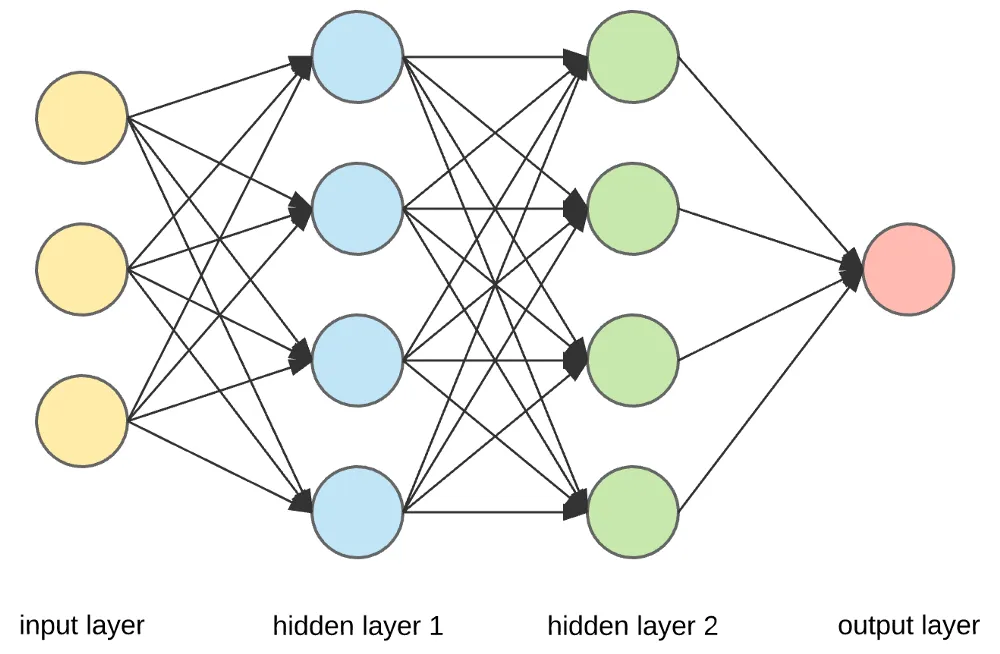

### 典型应用与局限性
应用: 应用：由于其强大的拟合能力，FCN 非常适合处理结构化数据（例如表格数据，如房价预测中的房屋面积、地段、房间数等）.


In [6]:
# 一个简单的全连接网络 , 使用 pytorch
import torch.nn as nn

class SimpleFCN(nn.Module):
    def __init__(self , input_size , num_classes):
        super(SimpleFCN , self).__init__()
        # 定义网络层
        self.fc1 = nn.Linear(input_size , 128)      # 第一隐藏层
        self.relu = nn.ReLU()                       # 激活函数
        self.fc2 = nn.Linear(128 , 64)              # 第二隐藏层
        self.fc3 = nn.Linear(64 , num_classes)      # 输出层

    def forward(self , x):
        x = self.fc1(x)                            # 输入层到第一隐藏层
        x = self.relu(x)                           # 激活函数
        x = self.fc2(x)                            # 第一隐藏层到第二隐藏层
        x = self.relu(x)                           # 激活函数
        x = self.fc3(x)                            # 第二隐藏层到输出层
        return x

# 假设输入特征维度为 100，分类数量为 10
model = SimpleFCN(input_size=100 , num_classes=10)
print(model)

SimpleFCN(
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


局限性 : 当处理图像、语音等网格化数据时，FCN 会面临巨大挑战。因为图像中的像素在空间上是高度相关的，而 FCN 会忽略这种空间结构，将图像拍平为一维向量进行处理，导致参数数量爆炸且难以学习有效的空间特征。因此，在处理图像等网格化数据时，卷积神经网络（CNN）成为了更合适的选择，因为它能够利用卷积操作捕捉局部特征，并通过权重共享减少参数数量，提高学习效率。

-----

## 卷积神经网络（CNN）- 计算机视觉的基石
为了解决全连接网络在处理图像等网格化数据时的局限性，卷积神经网络（CNN）应运而生。CNN 通过引入卷积层和池化层，能够有效地捕捉图像中的空间结构和局部特征。

### 核心思想 : 局部感知与参数共享
CNN 的设计灵感来源于生物视觉的视觉皮层 , 其两大核心思想是:
- 1. 局部感知:  不像 FCN 那样让神经元连接整个图像，CNN 的每个神经元只感受图像的一小块局部区域（如 3x3 或 5x5 的像素块）。这更符合图像中相邻像素关联性更强的特性。
- 2. 参数共享: 在卷积层中，同一卷积核（滤波器）在整个图像上滑动，提取相同类型的特征。这大大减少了参数数量，提高了学习效率，同时也增强了模型的泛化能力。

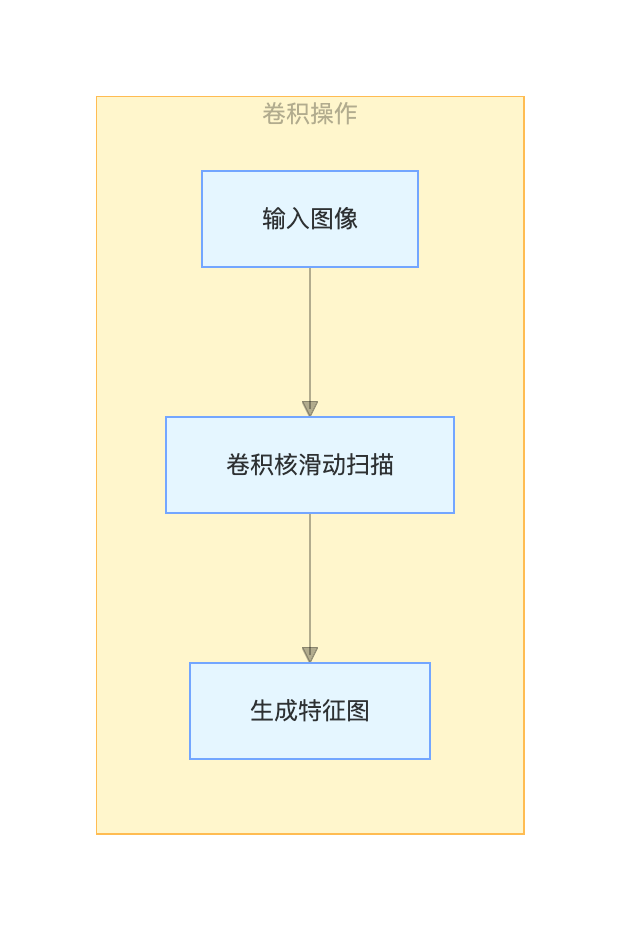

### 核心组件与典型应用  
一个典型的 CNN 由以下几个核心组件组成:
- 卷积层（Convolutional Layer）: 负责提取图像的局部特征，如边缘、纹理等。
- 池化层（Pooling Layer）: 通过下采样操作减少特征图的尺寸，降低计算复杂度，同时保留重要特征。
- 全连接层（Fully Connected Layer）: 在卷积层和池化层提取特征后，使用全连接层进行分类或回归等

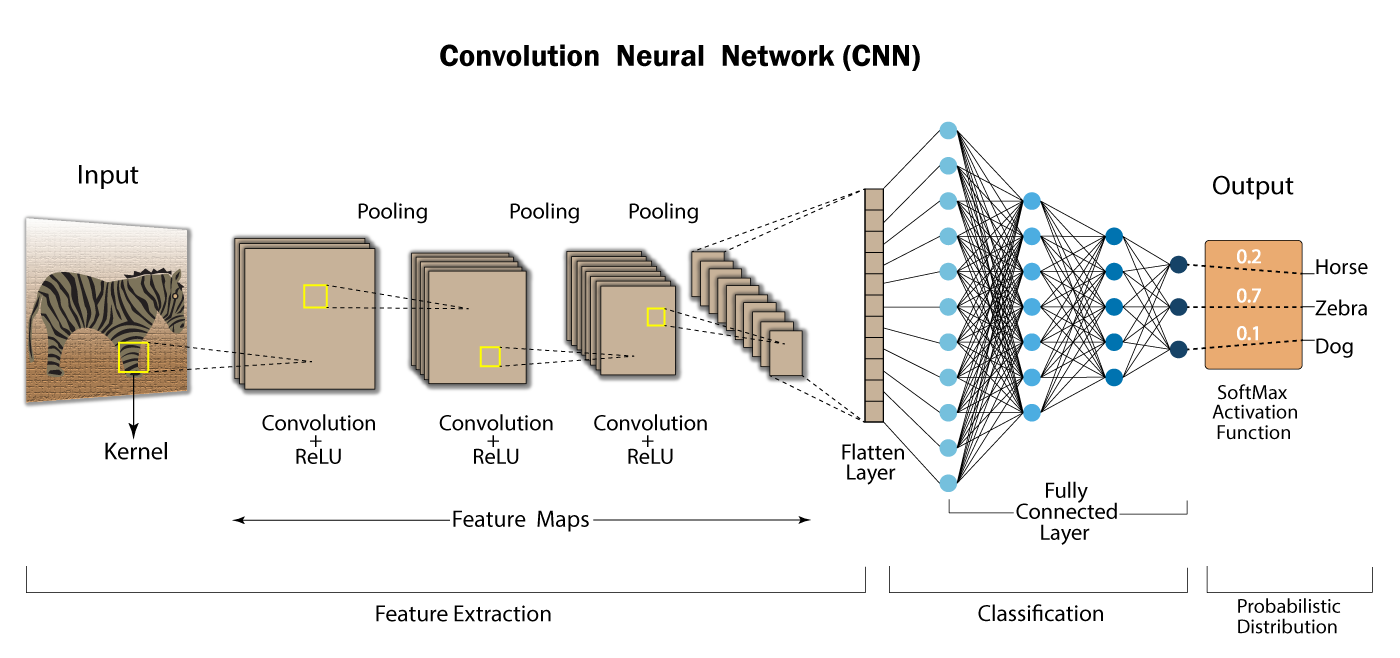

应用 : CNN 在计算机视觉领域的应用非常广泛，包括图像分类（如识别猫和狗）、目标检测（如自动驾驶中的行人检测）、图像分割（如医学影像分析）等。此外，CNN 也被应用于自然语言处理、语音识别等领域，展示了其强大的特征提取能力。

In [7]:
# 一个简单的CNN示例（用于图像分类）
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)    # 卷积层1
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)                                   # 池化层
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)                                        # 卷积层2
        self.fc1 = nn.Linear(32 * 8 * 8, 256)               # 假设经过两次池化后特征图大小为8x8
        self.fc2 = nn.Linear(256, num_classes)              # 输出层

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x))) # 卷积 -> 激活 -> 池化
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8) # 将特征图拍平成一维向量
        x = nn.functional.relu(self.fc1(x))
        x = self.fc2(x)
        return x

------

## 循环神经网络（RNN）- 序列数据的专家
对于语言、语音、时间序列等具有前后顺序依赖关系的数据，我们需要一种能记住历史信息的网络，这就是 循环神经网络。
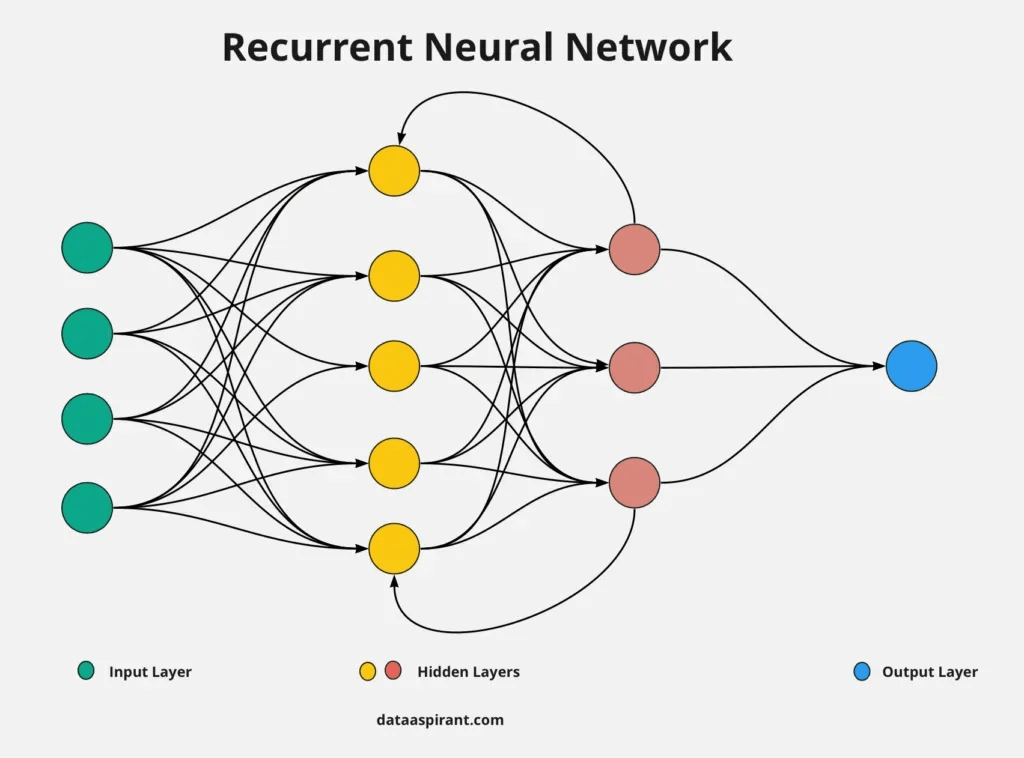

### 核心思想 : 引入记忆机制
RNN 的核心在于其循环结构。网络在处理当前输入时，会结合当前的输入和上一个时刻的隐藏状态，共同决定当前的输出和传递给下一个时刻的隐藏状态。这就像你在阅读一句话时，理解当前单词的含义需要依赖前面读过的单词。

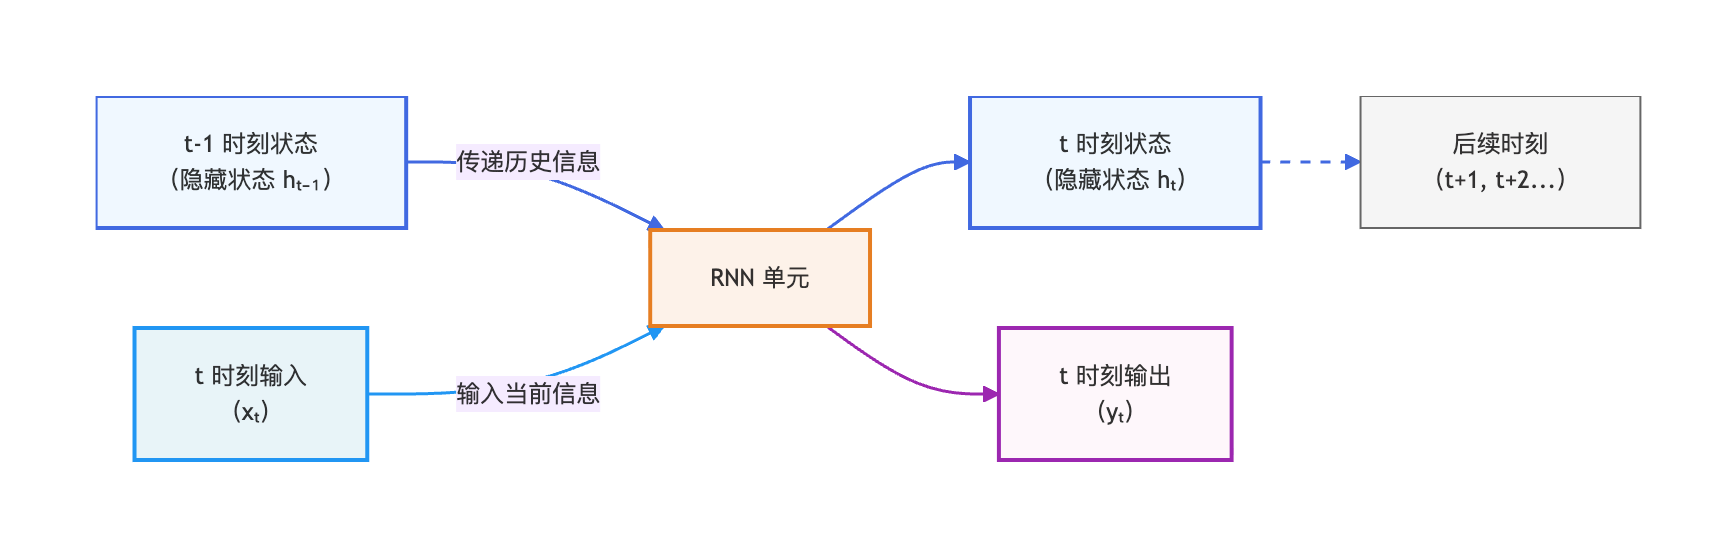

### 变体与典型应用
基础 RNN 存在长期依赖问题，难以学习长序列中的信息。因此产生了两个重要变体：
- 长短期记忆网络（LSTM）: 通过引入门控机制（输入门、遗忘门、输出门）来控制信息的流动，有效解决了长期依赖问题。
- 门控循环单元网络（GRU）: 是 LSTM 的简化版本，具有更少的参数，但在许多任务中表现与 LSTM 相当。

应用 : 机器翻译 , 文本生成 , 语音识别 , 时间序列预测等领域都广泛使用 RNN 及其变体，展示了其在处理序列数据方面的强大能力。

In [8]:
# 一个简单的RNN示例（用于文本情感分类）
class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes):
        super(SimpleRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size) # 词嵌入层
        self.rnn = nn.RNN(input_size=embed_size, hidden_size=hidden_size, batch_first=True)     # RNN层
        self.fc = nn.Linear(hidden_size, num_classes)    # 输出层

    def forward(self, x):
        # x 的形状: (batch_size, sequence_length)
        x = self.embedding(x) # 嵌入后: (batch_size, seq_len, embed_size)
        _, h_n = self.rnn(x)  # h_n 是最后一个时间步的隐藏状态
        out = self.fc(h_n.squeeze(0)) # 用最后的状态进行分类
        return out

-----

## 生成对抗网络（GAN）- 创造力的引擎
生成对抗网络（GAN）是一种非常独特的深度学习架构，由两部分组成：生成器（Generator）和判别器（Discriminator）。生成器的目标是生成逼真的数据（如图像），而判别器的目标是区分生成的数据和真实的数据。这种对抗训练的方式使得 GAN 能够生成非常逼真的数据，甚至达到以假乱真的程度。

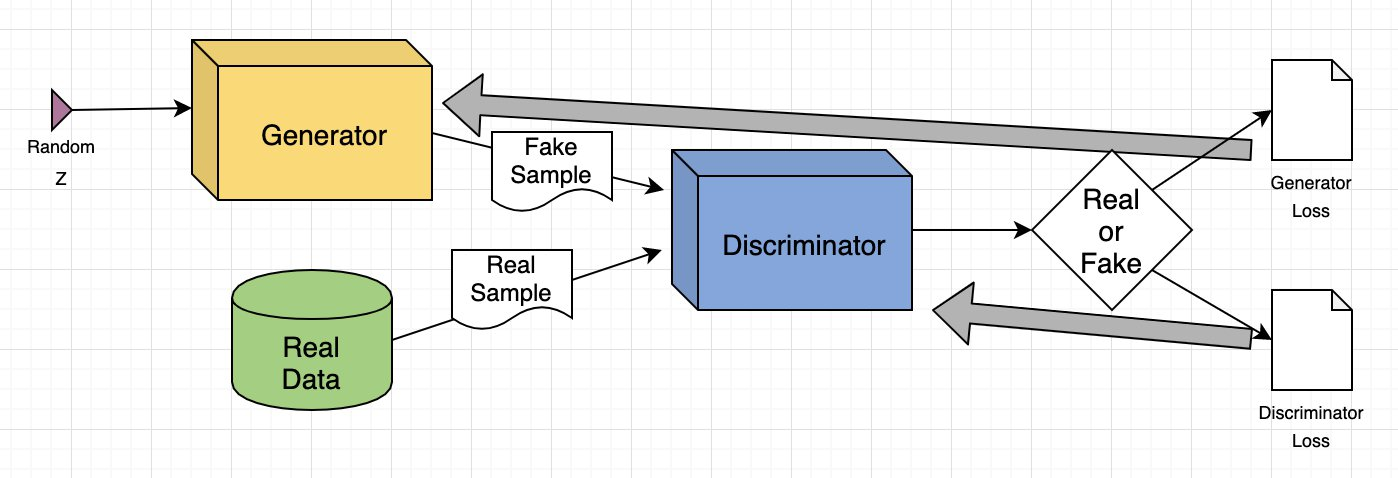

### 核心思想 : 在博弈中进化
GAN 的灵感来自博弈论。它由两个相互对抗的网络组成：

- 生成器：像一个造假者，目标是学习真实数据的分布，生成足以以假乱真的新数据。
- 判别器：像一个鉴定专家，目标是准确区分输入数据是来自真实数据集还是生成器。

两者在不断的对抗训练中共同进步：生成器努力生成更逼真的数据来骗过判别器，判别器则努力提高鉴别能力。最终，生成器能生成高质量的新数据。

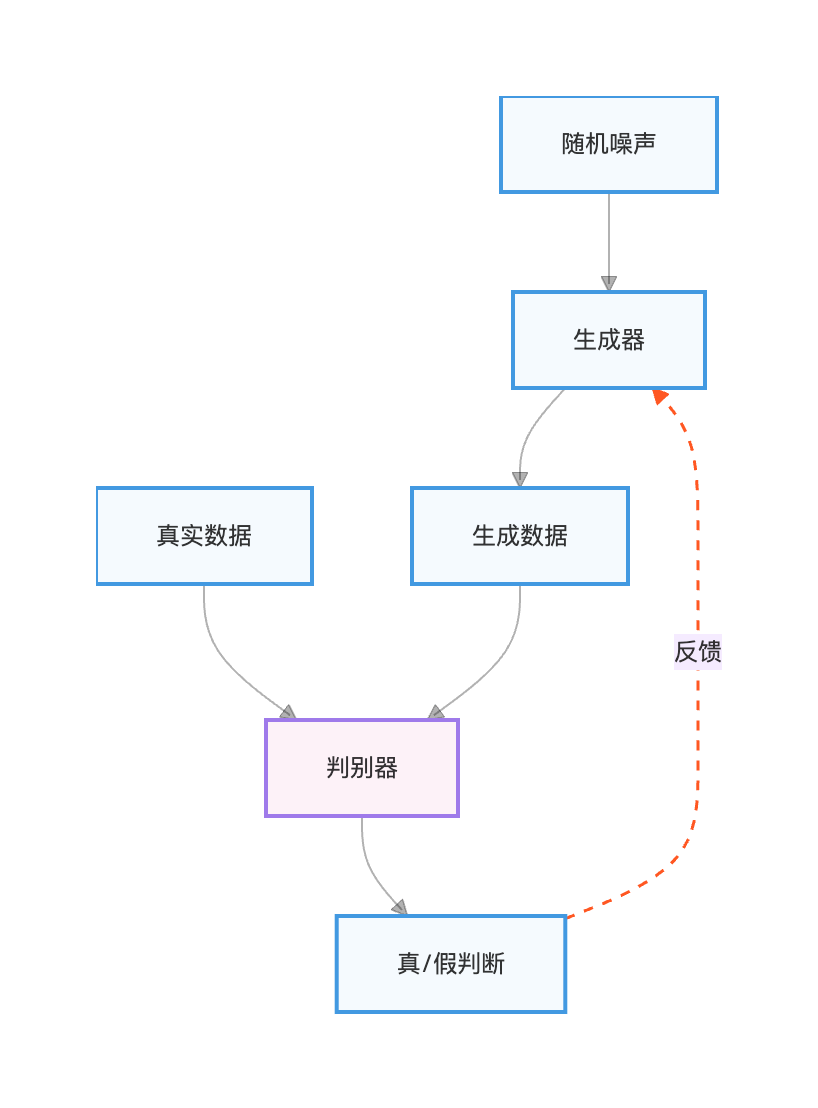

典型应用 : GAN 在图像生成（如人脸生成、艺术创作）、数据增强（如医学图像生成）、图像修复（如老照片修复）等领域有着广泛的应用。此外，GAN 也被用于文本生成、语音合成等任务，展示了其强大的创造力和多样性。

In [9]:
# GAN的核心训练循环伪代码示意
for epoch in range(num_epochs):
    # 1. 训练判别器：最大化判别真实数据为真、生成数据为假的能力
    real_data = get_real_data()
    noise = generate_random_noise()
    fake_data = generator(noise).detach() # 注意detach，防止生成器被更新

    d_loss_real = criterion(discriminator(real_data), real_labels)
    d_loss_fake = criterion(discriminator(fake_data), fake_labels)
    d_loss = d_loss_real + d_loss_fake
    d_loss.backward()
    optimizer_D.step()

    # 2. 训练生成器：最小化判别器将生成数据判为假的能力（即骗过判别器）
    noise = generate_random_noise()
    fake_data = generator(noise)
    g_loss = criterion(discriminator(fake_data), real_labels) # 让判别器认为生成的是真的
    g_loss.backward()
    optimizer_G.step()

NameError: name 'num_epochs' is not defined